In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
victorcallejasf_multimodal_hate_speech_path = kagglehub.dataset_download('victorcallejasf/multimodal-hate-speech')

print('Data source import complete.')


100%|██████████| 5.97G/5.97G [05:52<00:00, 18.2MB/s]

Extracting files...


Data source import complete.


In [ ]:
import subprocess
import sys

packages = [
    "torch>=2.0.0",
    "transformers>=4.36.0",
    "bitsandbytes>=0.41.0",
    "peft>=0.7.0",
    "pandas>=1.5.0",
    "numpy>=1.24.0",
    "scikit-learn>=1.3.0",
    "emoji>=2.0.0",
    "tqdm>=4.65.0",
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✓ All packages installed successfully!")

✓ All packages installed successfully!


In [ ]:
import os
import re
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, TaskType
import emoji

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def set_seed(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(42)

os.makedirs('./outputs', exist_ok=True)
print("Environment initialized. Outputs directory set to ./outputs")

Using device: cuda
✓ Environment initialized. Outputs directory set to ./outputs


In [ ]:
print("LOADING DATASET VIA KAGGLEHUB")
import os

dataset_path = "/root/.cache/kagglehub/datasets/victorcallejasf/multimodal-hate-speech/versions/1/MMHS150K_GT.json"

with open(dataset_path, 'r') as f:
    data = json.load(f)

print(f"✓ Loaded raw dictionary with {len(data):,} items.")

records = []
for tweet_id, info in data.items():
    text_val = info.get('tweet_text')
    labels_val = info.get('labels')

    if text_val:
        if isinstance(labels_val, list) and len(labels_val) > 0:
            maj_label = max(set(labels_val), key=labels_val.count)
        else:
            maj_label = 0

        records.append({
            'tweet_id': tweet_id,
            'text': str(text_val),
            'labels': labels_val,
            'majority_label': maj_label
        })

df = pd.DataFrame(records)
print(f"✓ Created basic DataFrame with shape: {df.shape}")

LOADING DATASET VIA KAGGLEHUB...
✓ Loaded raw dictionary with 149,823 items.
✓ Created basic DataFrame with shape: (149823, 4)


In [ ]:
print("MAPPING STRINGS AND NUMERIC LABELS...")
from collections import Counter

def majority_vote(labels):
    """Select most common label from annotators"""
    if isinstance(labels, list) and len(labels) > 0:
        label_count = Counter(labels)
        return label_count.most_common(1)[0][0]
    return 0  

label_str_mapping = {
    0: "NotHate",
    1: "Racist",
    2: "OtherHate",
    3: "Sexist",
    4: "Homophobe",
    5: "Religion"
}

# applymajority vote and map to clean text representation
df['majority_label'] = df['labels'].apply(majority_vote)
df['majority_label_str'] = df['majority_label'].map(label_str_mapping)
df['label'] = df['majority_label'].astype(int)

print("✓ Core targets mapped successfully!")
print("\nClass distribution in parsed dataset:")
print(df['majority_label_str'].value_counts())

MAPPING STRINGS AND NUMERIC LABELS...
✓ Core targets mapped successfully!

Class distribution in parsed dataset:
majority_label_str
NotHate      116790
Racist        14183
Religion       8196
OtherHate      5375
Sexist         4926
Homophobe       353
Name: count, dtype: int64


In [ ]:
# majority voting function
def majority_vote(labels):
    """Select most common label from annotators"""
    label_count = Counter(labels)
    return label_count.most_common(1)[0][0]

# label mapping (6 classes)
label_mapping = {
    0: "NotHate",
    1: "Racist",
    2: "Sexist",
    3: "Homophobe",
    4: "Religion",
    5: "OtherHate"
}

# apply majority vote
df['majority_label'] = df['labels'].apply(majority_vote)
df['majority_label_str'] = df['majority_label'].map(label_mapping)

print("Label mapping:")
for key, value in label_mapping.items():
    print(f"  {key}: {value}")

print("\nClass distribution BEFORE preprocessing:")
print(df['majority_label_str'].value_counts())
print()

Label mapping:
  0: NotHate
  1: Racist
  2: Sexist
  3: Homophobe
  4: Religion
  5: OtherHate

Class distribution BEFORE preprocessing:
majority_label_str
NotHate      116790
Racist        14183
OtherHate      8196
Sexist         5375
Homophobe      4926
Religion        353
Name: count, dtype: int64



In [ ]:
def clean_tweet_text(text):
    if not isinstance(text, str):
        return ""
    # convert emojis to text descriptors
    text = emoji.demojize(text, delimiters=(" ", " "))
    # remove URL links
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # remove user mentions
    text = re.sub(r'@\w+', '', text)
    # standardize spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning text rows...")
df['cleaned_text'] = df['text'].apply(clean_tweet_text)

df = df[df['cleaned_text'] != ""].reset_index(drop=True)
print(f"✓ Text cleaned. Remaining valid items: {len(df):,}")

Cleaning text rows...
✓ Text cleaned. Remaining valid items: 149,823


In [ ]:
from transformers import pipeline

print("LOADING SYNONYM GENERATOR MODEL...")
mask_filler = pipeline("fill-mask", model="xlm-roberta-base", device=0 if torch.cuda.is_available() else -1)

def contextualized_word_insertion(text, insertion_probability=0.3):
    words = text.split()
    if len(words) < 3:
        return text

    new_words = []
    for word in words:
        if np.random.rand() < insertion_probability and not word.startswith(('#', '@')):
            new_words.append(mask_filler.tokenizer.mask_token)
            new_words.append(word)
        else:
            new_words.append(word)

    masked_text = " ".join(new_words)[:512] 

    try:
        filled = mask_filler(masked_text)
        if isinstance(filled, list) and len(filled) > 0:
            if isinstance(filled[0], list): 
                return filled[0][0]['sequence']
            return filled[0]['sequence']
    except Exception:
        return text
    return text
print("✓ Generator infrastructure operational.")

LOADING SYNONYM GENERATOR MODEL...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] XLMRobertaForMaskedLM LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

✓ Generator infrastructure operational.


In [ ]:
print("STRATIFIED DOWNSAMPLING & MANAGED DATA AUGMENTATION")
from sklearn.model_selection import train_test_split

MAX_SAMPLES_PER_CLASS = 2000
balanced_records = []

for class_str in df['majority_label_str'].unique():
    class_subset = df[df['majority_label_str'] == class_str]
    if len(class_subset) > MAX_SAMPLES_PER_CLASS:
        # downsample the massive classes 
        class_subset = class_subset.sample(n=MAX_SAMPLES_PER_CLASS, random_state=42)
    balanced_records.append(class_subset)

df_balanced = pd.concat(balanced_records, ignore_index=True)

AUGMENTATION_MULTIPLIERS = {
    "NotHate": 1,
    "Racist": 2,       
    "OtherHate": 3,
    "Sexist": 4,
    "Homophobe": 5,
    "Religion": 10,    
}

print("Class distribution going into augmentation loop:")
print(df_balanced['majority_label_str'].value_counts())
print()

augmented_rows = []
print("Performing fast CWI augmentation on minority classes...\n")

for class_label, multiplier in AUGMENTATION_MULTIPLIERS.items():
    if multiplier == 1:
        continue

    class_data = df_balanced[df_balanced['majority_label_str'] == class_label]
    print(f"{class_label:15} : {len(class_data):4} samples → augmenting ×{multiplier}")

    for _, row in tqdm(class_data.iterrows(), total=len(class_data), leave=False):
        original_text = str(row['cleaned_text'])

        for _ in range(multiplier - 1):
            aug_text = contextualized_word_insertion(original_text, insertion_probability=0.2)
            new_row = row.copy()
            new_row['cleaned_text'] = str(aug_text)
            augmented_rows.append(new_row)

df_combined = pd.concat([df_balanced, pd.DataFrame(augmented_rows)], ignore_index=True)

print(f"\n✓ Augmentation complete successfully!")
print(f"  Total samples before: {len(df_balanced):,}")
print(f"  Total samples after:  {len(df_combined):,}")
print(f"\nFinal balanced class distribution:")
print(df_combined['majority_label_str'].value_counts())

STRATIFIED DOWNSAMPLING & MANAGED DATA AUGMENTATION
Class distribution going into augmentation loop:
majority_label_str
OtherHate    2000
NotHate      2000
Homophobe    2000
Racist       2000
Sexist       2000
Religion      353
Name: count, dtype: int64

Performing fast CWI augmentation on minority classes...

Racist          : 2000 samples → augmenting ×2


  0%|          | 7/2000 [00:00<02:41, 12.35it/s][transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


OtherHate       : 2000 samples → augmenting ×3


Sexist          : 2000 samples → augmenting ×4


Homophobe       : 2000 samples → augmenting ×5


Religion        :  353 samples → augmenting ×10



✓ Augmentation complete successfully!
  Total samples before: 10,353
  Total samples after:  33,530

Final balanced class distribution:
majority_label_str
Homophobe    10000
Sexist        8000
OtherHate     6000
Racist        4000
Religion      3530
NotHate       2000
Name: count, dtype: int64


In [ ]:
print("LOADING TINYLLAMA TOKENIZER")

model_id = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
print(f"Loading tokenizer from {model_id}...")
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"✓ Tokenizer loaded successfully!")
print(f"  Padding token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"  Padding side:  {tokenizer.padding_side}\n")

LOADING TINYLLAMA TOKENIZER
Loading tokenizer from TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T...
✓ Tokenizer loaded successfully!
  Padding token: </s> (ID: 2)
  Padding side:  left



In [ ]:
from sklearn.model_selection import train_test_split

print("SPLITTING AND TOKENIZING DATASETS")

train_df, temp_df = train_test_split(df_combined, test_size=0.2, random_state=42, stratify=df_combined['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

if len(train_df) > 15000:
    print(f"Downsampling training split to 15,000 rows for memory footprint balance...")
    train_df = train_df.sample(n=15000, random_state=42).reset_index(drop=True)
if len(val_df) > 2000:
    print(f"Downsampling validation split to 2,000 rows...")
    val_df = val_df.sample(n=2000, random_state=42).reset_index(drop=True)
if len(test_df) > 2000:
    print(f"Downsampling test split to 2,000 rows...")
    test_df = test_df.sample(n=2000, random_state=42).reset_index(drop=True)

def tokenize_dataframe(dataframe, tokenizer, max_len=128):
    texts = dataframe['cleaned_text'].astype(str).tolist()
    encodings = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )
    return encodings['input_ids'], encodings['attention_mask'], torch.tensor(dataframe['label'].values, dtype=torch.long)

print("Tokenizing train split...")
train_inputs, train_masks, train_labels = tokenize_dataframe(train_df, tokenizer)

print("Tokenizing validation split...")
val_inputs, val_masks, val_labels = tokenize_dataframe(val_df, tokenizer)

print("Tokenizing test split...")
test_inputs, test_masks, test_labels = tokenize_dataframe(test_df, tokenizer)

print("\n✓ Tokenization and dataset splitting complete.")

SPLITTING AND TOKENIZING DATASETS
Downsampling training split to 15,000 rows for memory footprint balance...
Downsampling validation split to 2,000 rows...
Downsampling test split to 2,000 rows...
Tokenizing train split...
Tokenizing validation split...
Tokenizing test split...

✓ Tokenization and dataset splitting complete.


In [23]:
print("CREATING DATASETS")

train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
val_dataset = TensorDataset(val_inputs, val_masks, val_labels)
test_dataset = TensorDataset(test_inputs, test_masks, test_labels)

print(f"✓ Datasets created:")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Val:   {len(val_dataset)} samples")
print(f"  Test:  {len(test_dataset)} samples\n")

CREATING DATASETS
✓ Datasets created:
  Train: 15000 samples
  Val:   2000 samples
  Test:  2000 samples



In [25]:
BATCH_SIZE = 8

train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=BATCH_SIZE)
validation_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=BATCH_SIZE)

print(f"✓ DataLoaders successfully mapped with a stable Batch Size of {BATCH_SIZE}.")

✓ DataLoaders successfully mapped with a stable Batch Size of 8.


In [ ]:
print("LOADING TINYLLAMA WITH 4-BIT QUANTIZATION (STABILIZED)")

print("Setting up 4-bit quantization (NF4) with bfloat16...")
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

model_id = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
print(f"Loading TinyLLaMA-1.1B with 4-bit quantization...")
model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=6,
    quantization_config=quantization_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)

model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

print(f"✓ Base model loaded and structural pad tokens aligned to ID: {model.config.pad_token_id}")

LOADING TINYLLAMA WITH 4-BIT QUANTIZATION (STABILIZED)
Setting up 4-bit quantization (NF4) with bfloat16...
Loading TinyLLaMA-1.1B with 4-bit quantization...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded and structural pad tokens aligned to ID: 2


In [28]:
print("CONFIGURING LORA (PEFT)...")

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("✓ LoRA parameters injected successfully.")

CONFIGURING LORA (PEFT)...
trainable params: 2,265,088 || all params: 1,036,789,760 || trainable%: 0.2185
✓ LoRA parameters injected successfully.


In [ ]:
EPOCHS = 15
total_steps = len(train_dataloader) * EPOCHS

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

print("✓ Optimizer and Linear Schedule defined.")

✓ Optimizer and Linear Schedule defined.


In [ ]:
import time

training_stats = []

print("Starting Training Loop with Numerical & DataType Safeguards...")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1} / {EPOCHS} ")
    t0 = time.time()

    if hasattr(model, "config"):
        model.config.pad_token_id = tokenizer.pad_token_id

    model.train()
    total_train_loss = 0
    skipped_batches = 0

    for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss

        if torch.isnan(loss):
            skipped_batches += 1
            continue

        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    effective_batches = len(train_dataloader) - skipped_batches
    avg_train_loss = total_train_loss / effective_batches if effective_batches > 0 else 0

    if skipped_batches > 0:
        print(f"  Warning: Skipped {skipped_batches} batches during this epoch due to NaN protections.")
    print(f"  Average training loss: {avg_train_loss:.4f}")

    # validation phase
    model.eval()
    total_eval_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(validation_dataloader, desc="Validating"):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)

        loss = outputs.loss
        total_eval_loss += loss.item()

        logits = outputs.logits.detach().float().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        all_preds.extend(np.argmax(logits, axis=1).flatten())
        all_labels.extend(label_ids.flatten())

    avg_val_loss = total_eval_loss / len(validation_dataloader)
    val_accuracy = accuracy_score(all_labels, all_preds)
    print(f"  Validation Loss: {avg_val_loss:.4f} | Validation Accuracy: {val_accuracy:.4f}")

    training_stats.append({
        'epoch': epoch + 1,
        'Training Loss': avg_train_loss,
        'Valid. Loss': avg_val_loss,
        'Valid. Accur.': val_accuracy
    })

print("\n✓ Training complete!")

Starting Training Loop with Numerical & DataType Safeguards...

Epoch 1 / 15 


Training: 100%|██████████| 1875/1875 [07:11<00:00,  4.35it/s]


  Average training loss: 0.8997


Validating: 100%|██████████| 250/250 [00:24<00:00, 10.40it/s]


  Validation Loss: 0.9052 | Validation Accuracy: 0.7045

Epoch 2 / 15 


...

  Validation Loss: 0.7692 | Validation Accuracy: 0.8160

Epoch 15 / 15 


Training: 100%|██████████| 1875/1875 [07:10<00:00,  4.36it/s]


  Average training loss: 0.0979


Validating: 100%|██████████| 250/250 [00:24<00:00, 10.36it/s]

  Validation Loss: 0.7692 | Validation Accuracy: 0.8160

✓ Training complete!


In [ ]:
print("Generating Detailed Validation Metrics...")

model.eval()
val_preds = []
val_labels = []
total_val_loss = 0

for batch in tqdm(validation_dataloader, desc="Evaluating Validation Set"):
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)

    loss = outputs.loss
    total_val_loss += loss.item()

    logits = outputs.logits.detach().float().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    val_preds.extend(np.argmax(logits, axis=1).flatten())
    val_labels.extend(label_ids.flatten())

avg_val_loss = total_val_loss / len(validation_dataloader)
val_accuracy = accuracy_score(val_labels, val_preds)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='weighted')

print("\nDETAILED VALIDATION REPORT ")
print(f"Average Validation Loss: {avg_val_loss:.4f}")
print(f"Validation Accuracy:     {val_accuracy * 100:.2f}%")
print(f"Weighted Precision:      {val_precision * 100:.2f}%")
print(f"Weighted Recall:         {val_recall * 100:.2f}%")
print(f"Weighted F1-Score:       {val_f1 * 100:.2f}%")

print("Per-Class Classification Report:")
print(classification_report(val_labels, val_preds, digits=4))

print("Confusion Matrix Layout:")
print(confusion_matrix(val_labels, val_preds))

Generating Detailed Validation Metrics...


Evaluating Validation Set: 100%|██████████| 250/250 [00:23<00:00, 10.42it/s]



DETAILED VALIDATION REPORT 
Average Validation Loss: 0.7692
Validation Accuracy:     81.60%
Weighted Precision:      81.04%
Weighted Recall:         81.60%
Weighted F1-Score:       81.16%
Per-Class Classification Report:
              precision    recall  f1-score   support

           0     0.4928    0.3063    0.3778       111
           1     0.6340    0.6622    0.6478       225
           2     0.7767    0.8239    0.7996       477
           3     0.9072    0.9441    0.9252       590
           4     0.9474    0.8963    0.9211       241
           5     0.8132    0.7949    0.8040       356

    accuracy                         0.8160      2000
   macro avg     0.7619    0.7380    0.7459      2000
weighted avg     0.8104    0.8160    0.8116      2000

Confusion Matrix Layout:
[[ 34  41  21   3   3   9]
 [ 19 149  24   5   6  22]
 [ 12  17 393  30   2  23]
 [  2   3  21 557   1   6]
 [  0   7   7   6 216   5]
 [  2  18  40  13   0 283]]


In [ ]:
print("Generating Final Evaluation Metrics on Test Dataset...")

model.eval()
test_preds = []
test_labels = []

for batch in tqdm(test_dataloader, desc="Testing"):
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)

    logits = outputs.logits.detach().float().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    test_preds.extend(np.argmax(logits, axis=1).flatten())
    test_labels.extend(label_ids.flatten())

precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='weighted')
test_accuracy = accuracy_score(test_labels, test_preds)

print("\n FINAL TEST RESULTS ")
print(f"Test Accuracy:  {test_accuracy * 100:.2f}%")
print(f"Precision:      {precision * 100:.2f}%")
print(f"Recall:         {recall * 100:.2f}%")
print(f"F1-Score:       {f1 * 100:.2f}%")

print("Detailed Classification Report:")
print(classification_report(test_labels, test_preds, digits=4))

Generating Final Evaluation Metrics on Test Dataset...


Testing: 100%|██████████| 250/250 [00:24<00:00, 10.42it/s]


 FINAL TEST RESULTS 
Test Accuracy:  79.80%
Precision:      79.43%
Recall:         79.80%
F1-Score:       79.48%
Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.4457    0.3306    0.3796       124
           1     0.6905    0.6932    0.6918       251
           2     0.7410    0.8323    0.7840       471
           3     0.9074    0.9151    0.9112       589
           4     0.9171    0.8826    0.8995       213
           5     0.7988    0.7443    0.7706       352

    accuracy                         0.7980      2000
   macro avg     0.7501    0.7330    0.7395      2000
weighted avg     0.7943    0.7980    0.7948      2000



Generating Dataset Sampling Distribution Plot...


/tmp/ipykernel_5870/2230481039.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


✓ Dataset distribution graph safely saved to: ./outputs/dataset_sampling_distribution.png


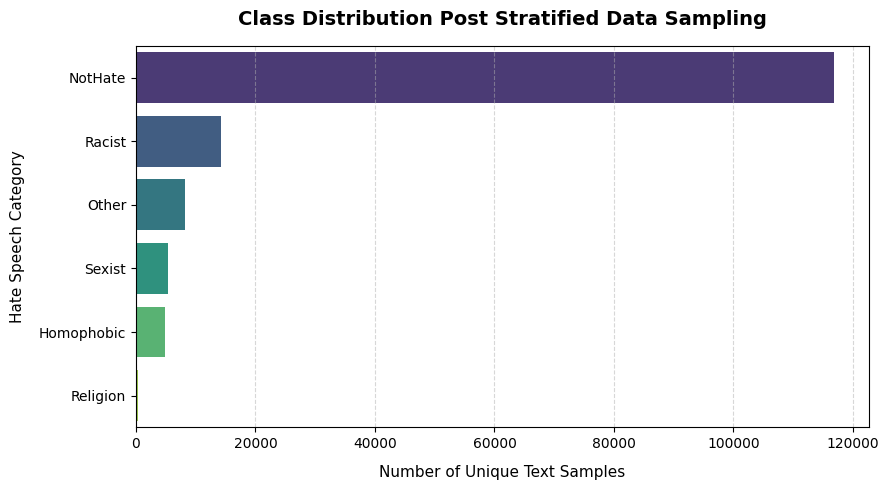

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating Dataset Sampling Distribution Plot...")

class_mapping = {
    0: 'NotHate',
    1: 'Racist',
    2: 'Sexist',
    3: 'Homophobic',
    4: 'Religion',
    5: 'Other'
}

counts = df['majority_label'].value_counts().reset_index()
counts.columns = ['Class_ID', 'Count']
counts['Category'] = counts['Class_ID'].map(class_mapping)

counts = counts.sort_values(by='Count', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x='Count',
    y='Category',
    data=counts,
    palette='viridis',
    ax=ax
)
ax.set_title('Class Distribution Post Stratified Data Sampling', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Unique Text Samples', fontsize=11, labelpad=10)
ax.set_ylabel('Hate Speech Category', fontsize=11, labelpad=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('./outputs/dataset_sampling_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Dataset distribution graph safely saved to: ./outputs/dataset_sampling_distribution.png")

Generating Confusion Matrix Graph...
✓ Confusion matrix graph safely saved to: ./outputs/confusion_matrix.png


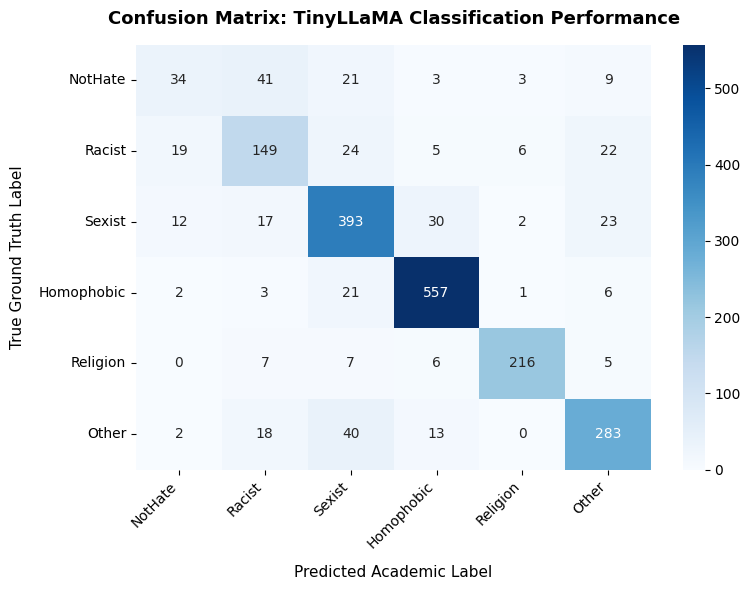

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating Confusion Matrix Graph...")

labels_order = ['NotHate', 'Racist', 'Sexist', 'Homophobic', 'Religion', 'Other']

cm = confusion_matrix(val_labels, val_preds)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_order,
    yticklabels=labels_order,
    cbar=True,
    ax=ax
)

ax.set_title('Confusion Matrix: TinyLLaMA Classification Performance', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Academic Label', fontsize=11, labelpad=10)
ax.set_ylabel('True Ground Truth Label', fontsize=11, labelpad=10)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('./outputs/confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix graph safely saved to: ./outputs/confusion_matrix.png")

Generating Training History Loss Curve...
✓ Convergence tracking history saved to: ./outputs/training_convergence_history.png


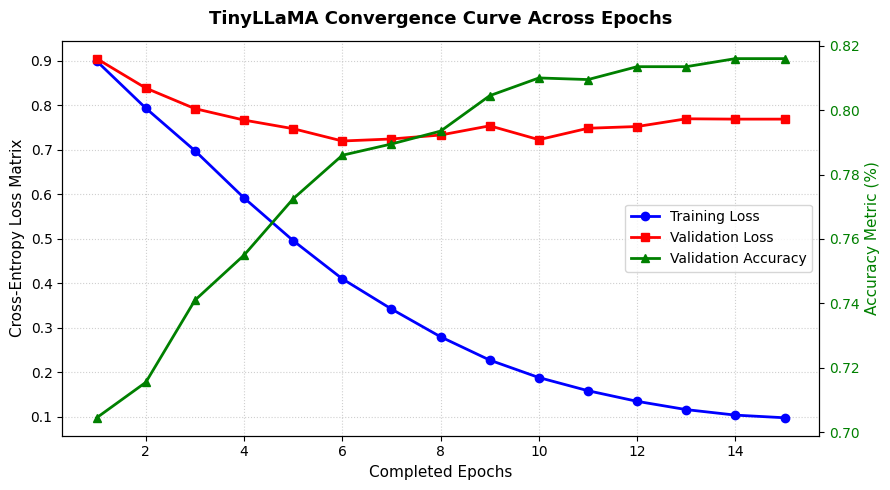

In [ ]:
print("Generating Training History Loss Curve...")

# parse dictionary tracking history to a dataframe
stats_df = pd.DataFrame(training_stats)

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(stats_df['epoch'], stats_df['Training Loss'], 'b-o', label='Training Loss', linewidth=2)
ax1.plot(stats_df['epoch'], stats_df['Valid. Loss'], 'r-s', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Completed Epochs', fontsize=11)
ax1.set_ylabel('Cross-Entropy Loss Matrix', color='black', fontsize=11)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(stats_df['epoch'], stats_df['Valid. Accur.'], 'g-^', label='Validation Accuracy', linewidth=2)
ax2.set_ylabel('Accuracy Metric (%)', color='green', fontsize=11)
ax2.tick_params(axis='y', labelcolor='green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('TinyLLaMA Convergence Curve Across Epochs', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('./outputs/training_convergence_history.png', dpi=300, bbox_inches='tight')
print("✓ Convergence tracking history saved to: ./outputs/training_convergence_history.png")

In [ ]:
MODEL_DIR = "./outputs/TinyLlama-1.1B-MMSH150K-LoRA"

model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f"✓ Model adapters safely written to: {MODEL_DIR}")

✓ Model adapters safely written to: ./outputs/TinyLlama-1.1B-MMSH150K-LoRA


In [ ]:
import shutil
from google.colab import files

ZIP_FILENAME = "tinyllama_lora_mmsh150k_results"

print(f"Archiving plots and model configurations into {ZIP_FILENAME}.zip...")
shutil.make_archive(ZIP_FILENAME, 'zip', './outputs')

print("✓ Archive complete. Triggering automatic download...")
files.download(f"{ZIP_FILENAME}.zip")

Archiving plots and model configurations into tinyllama_lora_mmsh150k_results.zip...
✓ Archive complete. Triggering automatic download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>